In [1]:
def accuracy(y_true, y_pred):
    correct_counter = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            correct_counter += 1
    return correct_counter / len(y_true)

In [2]:
l1 = [0, 1, 1, 1, 0, 0, 0, 1]
l2 = [0, 1, 0, 1, 0, 1, 0, 0]

accuracy(l1, l2)

0.625

In [3]:
from sklearn import metrics

metrics.accuracy_score(l1, l2)

0.625

In [4]:
def true_positive(y_true, y_pred):
    tp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
    return tp

def true_negative(y_true, y_pred):
    tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 0:
            tn += 1
    return tn

def false_positive(y_true, y_pred):
    fp = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 0 and yp == 1:
            fp += 1
    return fp

def false_negative(y_true, y_pred):
    fn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 0:
            fn += 1
    return fn

In [5]:
print(f'True positive: {true_positive(l1, l2)}')
print(f'True negative: {true_negative(l1, l2)}')
print(f'False positive: {false_positive(l1, l2)}')
print(f'False negative: {false_negative(l1, l2)}')

True positive: 2
True negative: 3
False positive: 1
False negative: 2


$$
accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

In [6]:
def accuracy_v2(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fp = false_positive(y_true, y_pred) 
    fn = false_negative(y_true, y_pred) 
    tn = true_negative(y_true, y_pred) 
    accuracy_score = (tp + tn) / (tp + tn + fp + fn) 
    return accuracy_score 

accuracy_v2(l1, l2)

0.625

$Precision = \frac{TP}{TP + FP}$

In [7]:
def precision(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fp = false_positive(y_true, y_pred) 
    precision = tp / (tp + fp) 
    return precision 

precision(l1, l2)

0.6666666666666666

The recall reflects the model's ability to identify actual positive samples.

$$
Recall = \frac{TP}{TP + FN}
$$

In [8]:
def recall(y_true, y_pred): 
    tp = true_positive(y_true, y_pred) 
    fn = false_negative(y_true, y_pred) 
    recall = tp / (tp + fn) 
    return recall

recall(l1, l2)

0.5

**Precision-Recall Curve**: For every threshold we choose, we calculate the precision and recall values, we can create a plot between these sets of values.

Text(0, 0.5, 'Precision')

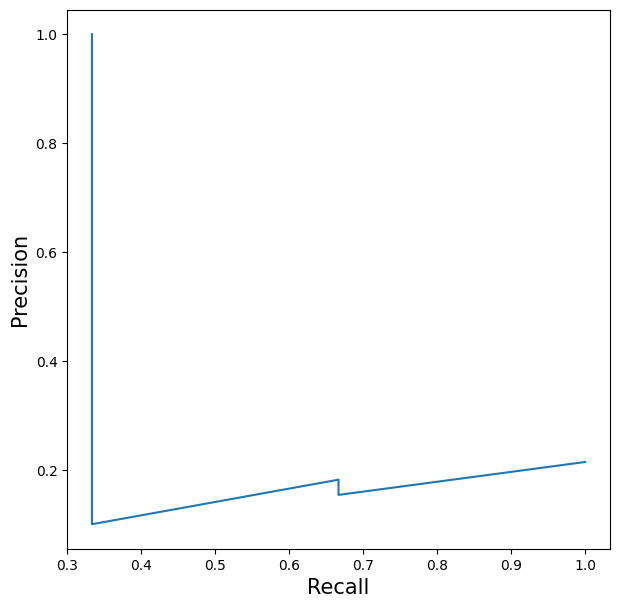

In [9]:
import matplotlib.pyplot as plt

y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_pred = [0.02638412, 0.11114267, 0.31620708,           
          0.0490937,  0.0191491,  0.17554844,        
          0.15952202, 0.03819563, 0.11639273, 
          0.079377,   0.08584789, 0.39095342, 
          0.27259048, 0.03447096, 0.04644807, 
          0.03543574, 0.18521942, 0.05934905, 
          0.61977213, 0.33056815] 

precisions = []
recalls = []
thresholds = [0.0490937 , 0.05934905, 0.079377,  
              0.08584789, 0.11114267, 0.11639273,  
              0.15952202, 0.17554844, 0.18521942,  
              0.27259048, 0.31620708, 0.33056815,  
              0.39095342, 0.61977213] 

for threshold in thresholds:
    prediction = [1 if x >= threshold else 0 for x in y_pred]
    p = precision(y_true, prediction)
    r = recall(y_true, prediction)
    precisions.append(p)
    recalls.append(r)

plt.figure(figsize=(7, 7))
plt.plot(recalls, precisions)
plt.xlabel('Recall', fontsize=15)
plt.ylabel('Precision', fontsize=15)

F1 score is a metric that combines both precision and recall. It is defined as a simple weighted average (harmonic mean) of precision and recall. If we denote precision using P and recall using R, we can represent the F1 score as:

$$
F1 = \frac{2PR}{P + R} = \frac{2TP}{2TP + FP + FN}
$$

In [11]:
def f1(y_true, y_pred): 
    p = precision(y_true, y_pred) 
    r = recall(y_true, y_pred) 
    score = 2 * p * r / (p + r) 
    return score

y_true = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0,      
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0] 
y_pred = [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 
          1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

f1(y_true, y_pred)

0.5714285714285715

In [12]:
from sklearn.metrics import f1_score
f1_score(y_true, y_pred)

0.5714285714285714